## FiLM Convolution
This is a sort of CNN context-aware

In [1]:
# %%
# Imports and configuration
import os
import sys
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT:
    sys.path.append(PROJECT_ROOT)
    print(f"✅ Added project root: {PROJECT_ROOT}")
else:
    print("❌ Project root not found.")
    sys.exit(1)

from config import settings
import config_film as cfg

# Import Dataset
try:
    from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
except ImportError:
    raise ImportError("Could not import BoaOpenFaceDataset.")

from _utils_ import dataset_utils

# --- Configuration ---
OUT_DIR = Path("./results_FiLM")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Training Hyperparameters
TARGET_LEN = cfg.TARGET_LEN          
BATCH_SIZE = cfg.BATCH_SIZE
NUM_EPOCHS = cfg.NUM_EPOCHS
LR = cfg.LR
WEIGHT_DECAY = cfg.WEIGHT_DECAY
PATIENCE = cfg.PATIENCE              
DEVICE = cfg.DEVICE
PRINT_EVERY = cfg.PRINT_EVERY
MODALITIES = cfg.MODALITIES
numeric_features = cfg.numeric_features
cat_features = cfg.cat_features

# %% --- Helpers ---
def ds_to_numpy_and_meta(ds, modalities=MODALITIES, target_len=TARGET_LEN):
    """
    Convert BoaOpenFaceDataset -> (X_ts [N,C,L], meta_df)
    """
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    X_list, metas = [], []
    
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map[m]
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        L = X.shape[0]
        
        # Pad/Truncate
        if L >= target_len:
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
            
        X_list.append(X_t.T)  # [C, L]
        
        # Metadata
        age = float(inst.age) if inst.age is not None else np.nan
        meta_row = {
            'pt_id': inst.pt_id,
            'trial_id': inst.trial_id,
            'label': int(inst.trial_type),
            'age': age,
            'sex': inst.sex if hasattr(inst, 'sex') else np.nan,
            'duration_s': L / getattr(ds, "FRAME_RATE", 25)
        }
        metas.append(meta_row)
        
    X_arr = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(metas)
    return X_arr, meta_df


✅ Added project root: /home/phd2/Scrivania/CorsoRepo/Bambino


In [2]:
# %% --- Load Data ---
print("\n📂 Loading datasets...")
# Using the pre-normalized augmented dataset
DATASET_TYPE = 'augmented_normalized' 

TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds   = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds  = BoaOpenFaceDataset.load_dataset(TEST_PATH)

print(f"Instances: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")

# Convert to Numpy
X_train_ts, df_train_meta = ds_to_numpy_and_meta(train_ds)
X_val_ts,   df_val_meta   = ds_to_numpy_and_meta(val_ds)
X_test_ts,  df_test_meta  = ds_to_numpy_and_meta(test_ds)

y_train = df_train_meta['label'].values
y_val   = df_val_meta['label'].values
y_test  = df_test_meta['label'].values

# Process Metadata
print("   Processing Metadata...")
meta_preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

X_meta_train = meta_preproc.fit_transform(df_train_meta[numeric_features + cat_features])
X_meta_val   = meta_preproc.transform(df_val_meta[numeric_features + cat_features])
X_meta_test  = meta_preproc.transform(df_test_meta[numeric_features + cat_features])


# %% --- PyTorch Setup ---
def build_loader(X_ts, X_meta, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_ts, dtype=torch.float32),
        torch.tensor(X_meta, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    # n_workers > 0 helps if you have RAM, set to 0 if it crashes
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = build_loader(X_train_ts, X_meta_train, y_train, shuffle=True)
val_loader   = build_loader(X_val_ts, X_meta_val, y_val, shuffle=False)
test_loader  = build_loader(X_test_ts, X_meta_test, y_test, shuffle=False)

# %% --- FiLM Model Definition ---
class ConvFiLM(nn.Module):
    def __init__(self, in_channels, meta_dim, channels=(8, 16), kernel_size=3, dropout=0.6, head_dim=16): # Reduced head_dim
        super().__init__()
        
        # CNN Backbone (Tiny)
        self.conv1 = nn.Conv1d(in_channels, channels[0], kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(channels[0])
        
        self.conv2 = nn.Conv1d(channels[0], channels[1], kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(channels[1])
        
        # FiLM Generators (Bottlenecked)
        # Force the model to compress metadata info before modulating
        self.film1 = nn.Sequential(
            nn.Linear(meta_dim, 8), # Bottleneck
            nn.ReLU(),
            nn.Linear(8, channels[0] * 2)
        )
        self.film2 = nn.Sequential(
            nn.Linear(meta_dim, 8), # Bottleneck
            nn.ReLU(),
            nn.Linear(8, channels[1] * 2)
        )
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification Head (Simpler)
        head_in = channels[1] + meta_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, head_dim), # Smaller hidden layer
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, 1)
        )
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            
        # FiLM Init (Identity)
        if hasattr(self, 'film1'):
            nn.init.normal_(self.film1[-1].weight, 0, 0.01) # Target the last linear layer
            nn.init.constant_(self.film1[-1].bias, 0)
            self.film1[-1].bias.data[:self.film1[-1].out_features//2].fill_(1.0)

    def forward(self, x, meta):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        
        # Apply FiLM 1
        params1 = self.film1(meta)
        gamma1, beta1 = params1.chunk(2, dim=1)
        x = x * gamma1.unsqueeze(-1) + beta1.unsqueeze(-1)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        # Apply FiLM 2
        params2 = self.film2(meta)
        gamma2, beta2 = params2.chunk(2, dim=1)
        x = x * gamma2.unsqueeze(-1) + beta2.unsqueeze(-1)
        
        # Pool & Head
        x = self.pool(x).squeeze(-1)
        x_cat = torch.cat([x, meta], dim=1)
        return self.head(x_cat).squeeze(-1)

# Initialize Model
model = ConvFiLM(
    in_channels=X_train_ts.shape[1], 
    meta_dim=X_meta_train.shape[1],
    channels=getattr(cfg, 'channels', (8, 16) ),    
    kernel_size=getattr(cfg, 'kernel_size', 3),
    dropout=getattr(cfg, 'dropout', 0.6),
    head_dim=getattr(cfg, 'head_dim', 32)
).to(DEVICE)

print(f"\n🧠 Model Initialized on {DEVICE}")



📂 Loading datasets...
Instances: Train 1970, Val 140, Test 137
   Processing Metadata...

🧠 Model Initialized on cuda


In [3]:
# %% --- Training Loop with OneCycleLR ---
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05) # Increased WD

# OneCycle Scheduler: Helps convergence on small data
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=3e-3, 
    steps_per_epoch=len(train_loader), 
    epochs=NUM_EPOCHS
)

best_val_score = -1.0
best_model_state = None
epochs_no_improve = 0

print(f"\n🚀 Starting Training for {NUM_EPOCHS} epochs (OneCycle)...")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    
    for xb, xm, yb in train_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb, xm)
        loss = criterion(logits, yb)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step() # Step every batch for OneCycle
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, xm, yb in val_loader:
            xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
            logits = model(xb, xm)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(yb.cpu().numpy())
            
    val_loss /= len(val_loader)
    
    # Validation Metrics
    preds_arr = np.array(all_preds)
    labels_arr = np.array(all_labels)
    
    best_thr = 0.5
    best_bal = 0.0
    for thr in np.linspace(0.3, 0.7, 20): # Narrow search range
        p = (preds_arr >= thr).astype(int)
        bal = balanced_accuracy_score(labels_arr, p)
        if bal > best_bal:
            best_bal = bal
            best_thr = thr
            
    # Save Best Model
    if best_bal > best_val_score:
        best_val_score = best_bal
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BalAcc: {best_bal:.4f}")
        
    if epochs_no_improve >= PATIENCE:
        print(f"⏹️ Early stopping at epoch {epoch}")
        break


🚀 Starting Training for 40 epochs (OneCycle)...
Epoch 01 | Train Loss: 0.7215 | Val Loss: 0.6417 | Val BalAcc: 0.5491
Epoch 02 | Train Loss: 0.7189 | Val Loss: 0.6548 | Val BalAcc: 0.6071
Epoch 03 | Train Loss: 0.6989 | Val Loss: 0.6563 | Val BalAcc: 0.5982
Epoch 04 | Train Loss: 0.6899 | Val Loss: 0.6729 | Val BalAcc: 0.5759
Epoch 05 | Train Loss: 0.6559 | Val Loss: 0.6655 | Val BalAcc: 0.5893
Epoch 06 | Train Loss: 0.6015 | Val Loss: 0.6126 | Val BalAcc: 0.6295
Epoch 07 | Train Loss: 0.5404 | Val Loss: 0.6038 | Val BalAcc: 0.5625
Epoch 08 | Train Loss: 0.5190 | Val Loss: 0.7095 | Val BalAcc: 0.6071
Epoch 09 | Train Loss: 0.4797 | Val Loss: 0.6872 | Val BalAcc: 0.5179
Epoch 10 | Train Loss: 0.4685 | Val Loss: 0.8024 | Val BalAcc: 0.5625
Epoch 11 | Train Loss: 0.4314 | Val Loss: 0.8248 | Val BalAcc: 0.5223
Epoch 12 | Train Loss: 0.4317 | Val Loss: 0.6736 | Val BalAcc: 0.5134
Epoch 13 | Train Loss: 0.3998 | Val Loss: 0.6928 | Val BalAcc: 0.5312
Epoch 14 | Train Loss: 0.3916 | Val Loss:

Is it possible to use shap or smt similar for this model? is gradcam better? or smt else? Be aware that everything was working. Could you provide me with only the new section?


📝 Evaluating on Test Set...

TEST Balanced Accuracy: 0.5576
TEST MCC: 0.1071

Classification Report:
              precision    recall  f1-score   support

         0.0     0.2727    0.3333    0.3000        27
         1.0     0.8269    0.7818    0.8037       110

    accuracy                         0.6934       137
   macro avg     0.5498    0.5576    0.5519       137
weighted avg     0.7177    0.6934    0.7045       137



<Figure size 600x500 with 0 Axes>

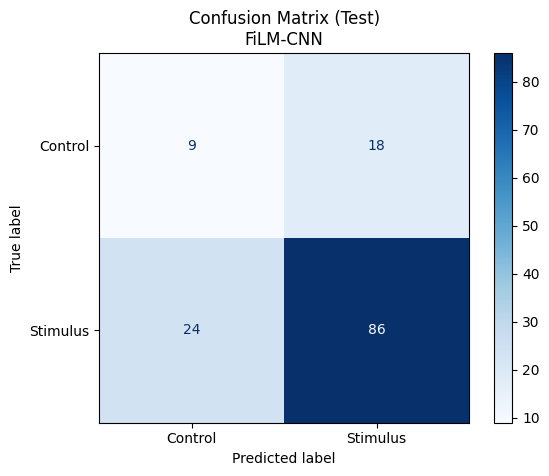

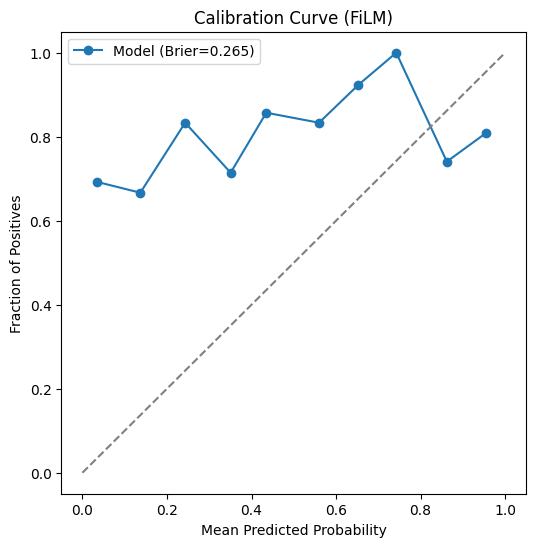


👶 Per-Baby Performance Analysis...

Per-Baby F1 Scores (Test):
------------------------------------------------------------
BabyID: bam1_008   | Age: 6.70  | Sex: F   | F1 Score: 0.7407
BabyID: bam1_026   | Age: 6.54  | Sex: F   | F1 Score: 0.7586
BabyID: bam1_044   | Age: 6.08  | Sex: M   | F1 Score: 0.7742
BabyID: bam1_005   | Age: 5.42  | Sex: F   | F1 Score: 0.7857
BabyID: bam1_018   | Age: 4.96  | Sex: M   | F1 Score: 0.8125
BabyID: bam1_020   | Age: 4.83  | Sex: F   | F1 Score: 0.8571
BabyID: bam1_024   | Age: 6.41  | Sex: F   | F1 Score: 0.8750
------------------------------------------------------------


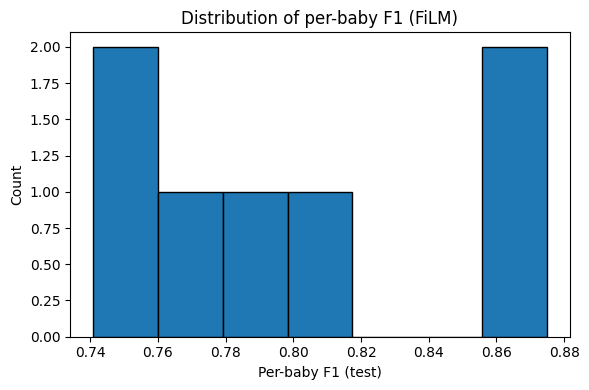

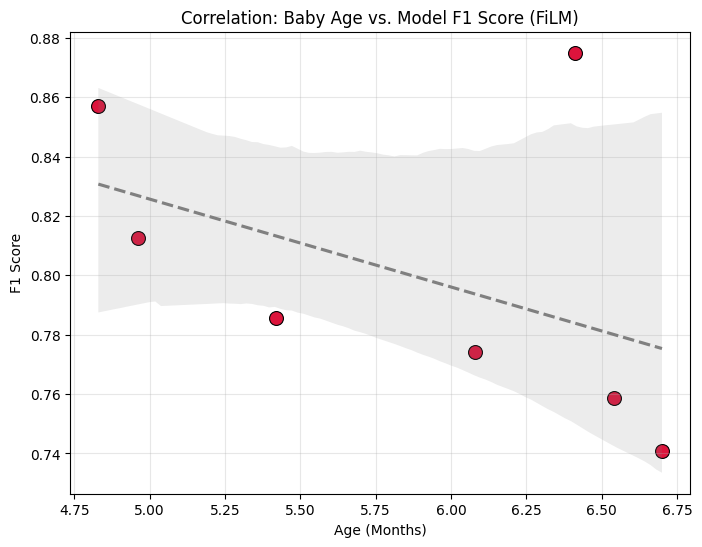


✅ Analysis Complete. Results saved to results_FiLM


In [5]:
# %% --- Evaluation ---
print("\n📝 Evaluating on Test Set...")
model.load_state_dict(best_model_state)
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for xb, xm, yb in test_loader:
        xb, xm = xb.to(DEVICE), xm.to(DEVICE)
        logits = model(xb, xm)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(yb.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# Final Metrics
y_pred_test = (test_probs >= best_thr).astype(int)
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print(f"\nTEST Balanced Accuracy: {bal_test:.4f}")
print(f"TEST MCC: {mcc_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Save Text Report
with open(OUT_DIR / "film_classification_report_test.txt", "w") as f:
    f.write(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Test)\nFiLM-CNN")
plt.savefig(OUT_DIR / "film_confusion_matrix_test.png")
plt.show()

# Calibration Curve
frac_pos, mean_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Model (Brier={brier_test:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (FiLM)')
plt.legend()
plt.savefig(OUT_DIR / "film_calibration_curve_test.png")
plt.show()

# %% --- Detailed Per-Baby Analysis ---
print("\n👶 Per-Baby Performance Analysis...")

pt_ids = df_test_meta['pt_id'].unique()
per_baby_details = []
per_baby_f1_list = []

# Use metadata directly to map back (order preserved)
df_test_meta['pred_prob'] = test_probs
df_test_meta['pred_label'] = y_pred_test
df_test_meta['true_label'] = test_labels

for pid in pt_ids:
    sub = df_test_meta[df_test_meta['pt_id'] == pid]
    if len(sub) < 2: continue
    
    f1 = f1_score(sub['true_label'], sub['pred_label'], zero_division=0)
    
    age = sub['age'].iloc[0]
    sex_val = sub['sex'].iloc[0]
    sex_str = "F" if str(sex_val) == "0" else "M" if str(sex_val) == "1" else str(sex_val)
    
    per_baby_details.append((pid, age, sex_str, f1))
    per_baby_f1_list.append(f1)

# 1. Print Inline List (Sorted by F1)
per_baby_details.sort(key=lambda x: x[3])
print("\nPer-Baby F1 Scores (Test):")
print("-" * 60)
for pid, age, sex, f1 in per_baby_details:
    print(f"BabyID: {pid:<10} | Age: {age:<5.2f} | Sex: {sex:<3} | F1 Score: {f1:.4f}")
print("-" * 60)

# 2. Histogram (Matching previous models)
if per_baby_f1_list:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_f1_list, bins=min(20, len(per_baby_f1_list)), edgecolor='black')
    plt.xlabel('Per-baby F1 (test)')
    plt.ylabel('Count')
    plt.title('Distribution of per-baby F1 (FiLM)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'film_per_baby_f1_hist.png')
    plt.show()

# 3. Scatter Plot: Age vs F1 (New Addition)
ages = [x[1] for x in per_baby_details]
f1s = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=f1s, s=100, color='crimson', edgecolor='black')
# Add trendline
sns.regplot(x=ages, y=f1s, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model F1 Score (FiLM)")
plt.xlabel("Age (Months)")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "film_age_vs_f1_scatter.png")
plt.show()

print("\n✅ Analysis Complete. Results saved to", OUT_DIR)